In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Cell 2: Load the data
df = pd.read_csv('../data/creditcard.csv')

print(f"Dataset loaded!")
print(f"Total transactions: {len(df):,}")
print(f"Number of features: {df.shape[1]}")

Dataset loaded!
Total transactions: 284,807
Number of features: 31


In [3]:
# Cell 3: Look at the first few rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Cell 4: Basic statistics
print("Basic Information:")
print(df.info())
print("\n" + "="*50 + "\n")
print("Statistical Summary:")
print(df.describe())

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  floa

Legitimate transactions: 284,315 (99.827%)
Fraudulent transactions: 492 (0.173%)


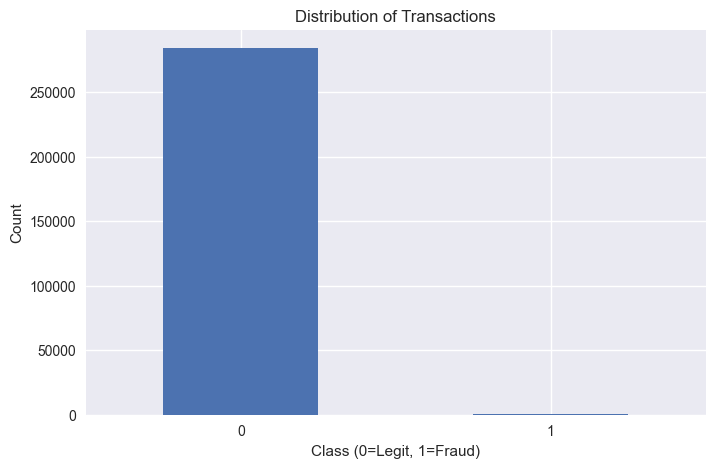

In [5]:
# Cell 5: Check class distribution
fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_percentage = (fraud_count / len(df)) * 100

print(f"Legitimate transactions: {legit_count:,} ({100-fraud_percentage:.3f}%)")
print(f"Fraudulent transactions: {fraud_count:,} ({fraud_percentage:.3f}%)")

# Visualize
plt.figure(figsize=(8, 5))
df['Class'].value_counts().plot(kind='bar')
plt.title('Distribution of Transactions')
plt.xlabel('Class (0=Legit, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

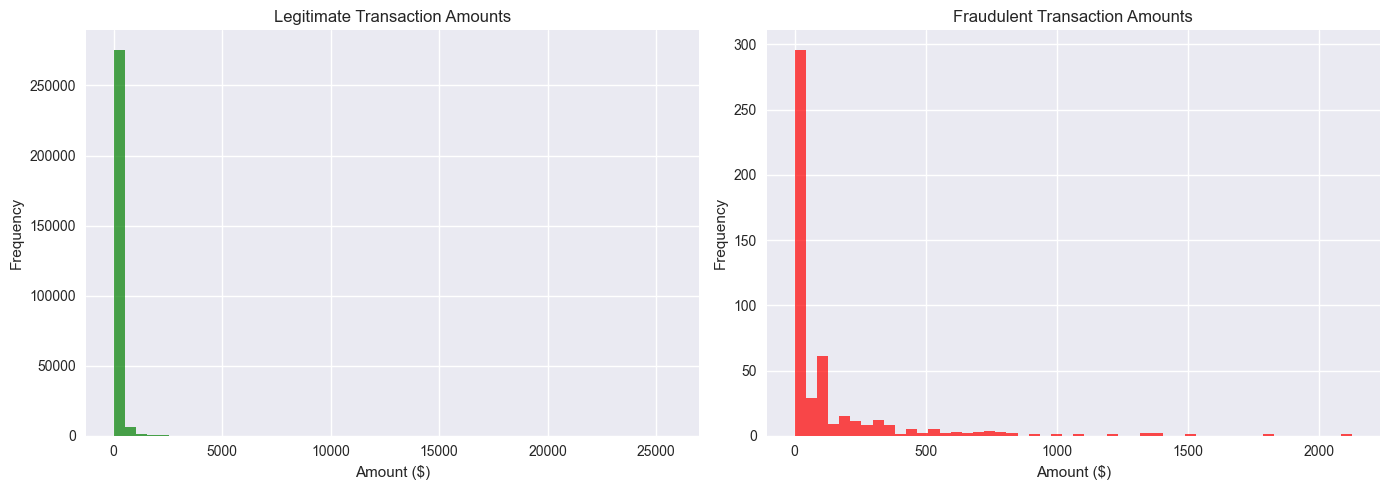

Average legitimate transaction: $88.29
Average fraudulent transaction: $122.21


In [6]:
# Cell 6: Analyze transaction amounts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Legitimate transactions
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='green', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

# Fraudulent transactions
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='red', alpha=0.7)
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Average legitimate transaction: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Average fraudulent transaction: ${df[df['Class']==1]['Amount'].mean():.2f}")

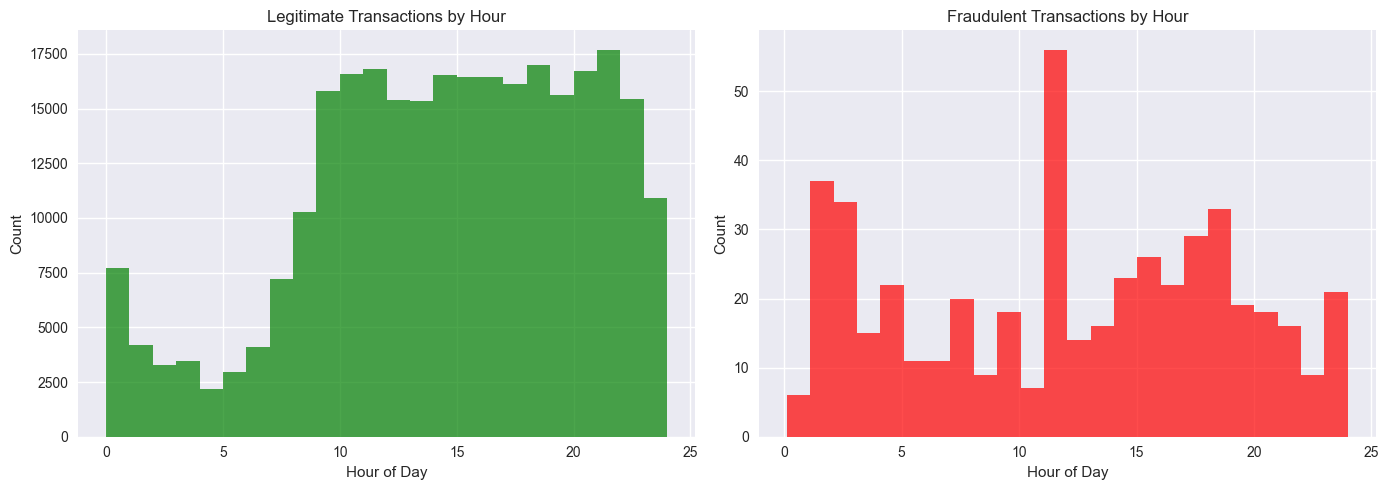

In [9]:
# Cell 7: Time analysis
df['Hour'] = (df['Time'] / 3600) % 24  # Convert to hour of day

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Legitimate by hour
df[df['Class']==0]['Hour'].hist(bins=24, ax=axes[0], color='green', alpha=0.7)
axes[0].set_title('Legitimate Transactions by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')

# Fraud by hour
df[df['Class']==1]['Hour'].hist(bins=24, ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('Fraudulent Transactions by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


# **Why this matters:**
# - Maybe fraudsters operate at specific times?
# - This could be a valuable feature!

# ---

### **Lesson 1.4: Understanding Key Concepts**

# **Before we move to modeling, let's understand some terms:**

# **1. Features (X) vs Target (y)**
# - **Features**: Information we use to predict (Amount, Time, V1-V28)
# - **Target**: What we're predicting (Class: fraud or not)

# **2. Train-Test Split**
# ```
# All Data → Split → Training Data (80%) → Train Model
#                  → Test Data (20%) → Evaluate Model
# ```
# **Why?** We need unseen data to check if the model truly learned, not just memorized!

# **3. Imbalanced Data Problem**
# ```
# Legitimate: 99.8% ████████████████████████
# Fraud:       0.2% █
# ```
# **Problem**: Model might just say "everything is legitimate" and be 99.8% accurate but useless!

# **Solution techniques we'll use:**
# - **SMOTE**: Create synthetic fraud examples
# - **Class weights**: Tell model "fraud errors are more costly"
# - **Better metrics**: Don't use accuracy, use precision/recall

# **4. Model Evaluation Metrics**

# Imagine a fraud detector:
# ```
# Predicted Fraud │ Actually Fraud │ Actually Legit
# ─────────────────┼────────────────┼────────────────
#     Fraud       │  TP (Good!)    │  FP (Bad - False Alarm!)
#     Legit       │  FN (Bad! Missed Fraud) │ TN (Good!)